<a href="https://colab.research.google.com/github/kundana12345/DataScience/blob/main/KundAddaU7proj.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Your file on your github needs to be a a .ipynb file with the first four letters of one first name, the first four letters of one last name, and U6proj.

Ex1.

A student named Avy Aguacate Avocado Palta will submit a file named "Avy_AvocU7proj.ipynb", since she normally just goes by Avy, and, when pressed, reports Avocado as her last name. The " _ " after "Avy" serves as the fourth "letter" in her first name.

Ex2.

Army Armadillo will submit a file named "ArmyArmaU7proj.ipynb"

# Unit 7 Project: Polynomials, Splines, and GPs, Oh my!

**Task**:

Two parts:

1. Propose a data set that's compatible with pymc and/or bambi. I must approve your submission before you move on to part 2.

2. Create, analyze, and present any guassian process or approximate GP, degenerate or otherwise (this means glms and b splines are allowed), using pymc within the colab environment, on a data set of your choice, with the following conditions:
  - your final model must have more than 2 predictors. The intercept term doesn't count as a predictor here (even though technically it is), or if must be an actual GP
  - You must document and explain your model selection method. This means you must argue that your model choice (glm, b spline, GP) is better than at least one other choice. You may use either a theoretical or numerical argument.



Guidlines:

- Your data or your model type must be different from any project you've previously done.

- You are allowed to copy and paste any code from the notes, including my answer key (AK), without any reference or citations. Same goes for the course textbook, BAP3.

- This is an individual project. It is fine if you model the same process as a peer, but your raw data **must** be substantially different. "Substantially different" means that I, your instructor, arbitrarily think your data sets are different enough.

- Do not look at other student's code/jupyter notebooks. Copying, or copying and pasting, other students code will result in a failing grade. Also, I will tell all the other teachers I know that you cheated.

- If you want to know what another student did, ask them--any verbal communication about a project is allowed and encouraged. If you want to see a graphic they made, ask them to sketch a picture of it for you by hand.

- Any handwritten communication is also allowed and encouraged, so long as all parties are in the same physical location together. Example: you may sketch out a piece of code while verbally explaining to someone what you did. Do NOT: hand write the code for your entire project, take a picture, and send it to everyone in the course.

- If you use someone's code from outside this course (like from the internet, an AI, or your parent), you must ask me if it is ok, and you must cite them in your work. I don't care all they did was to click your space bar one more time: you tell me, and you cite their contribution. You don't need to tell me about or cite verbal or handwritten communication though.

- You may use a more complicated model--like something from further along in the course--IF I give you permission.

- If you are unsure whether or not something is ok or allowed: ASK BEFORE YOU DO IT.

Faliure to adhere to these guidlines will result in a failing grade.

Tips:

- Try to pick something that you care about, have knowledge of, experience with, or that you find interesting/cool.

- Gather data *before* picking a model or likelihood.

-  Use your best idea now; maybe you can look at the context you used in the previous project, and gather different data from it.

- Choose a data set with lots of columns, and lots of potential interactions between variables. It'll be more fun, and will make model/variable selection more relevant.

- This is not a competition to come up with the fanciest model structure. Find a data set that interests you, and apply the simplest model that captures the patterns in the data.

- Comment heavily, and explain your steps and thought process with text blocks. This is not only requried, it'll also help you understand what you're doing and what you want to do.

- I actually encourge you to use b splines; they work quite well, and trying to determine the location of the knots requires careful thought about the context of the data.

- Its ok to pick a data set for which you don't qute understand the context--so long as you think the context is cool.


This data is body fat data for several different ages and different parts of the body. I think that for each pair of features, there will be a general positive association between the two because if there is more fat in general, there will be more fat in different parts as well.

In [3]:
import numpy as np
import pandas as pd
import arviz as az
import pymc as pm
import graphviz as gv
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
prod = pd.read_csv('https://raw.githubusercontent.com/thedarredondo/data-science-fundamentals/main/Data/body_fat.csv')

In [5]:
prod

,siri,age,weight,height,abdomen,thigh,wrist
0,12.3,23,70.1,172,85.2,59.0,17.1
1,6.1,22,78.8,184,83.0,58.7,18.2
2,25.3,22,70.0,168,87.9,59.6,16.6
3,10.4,26,84.0,184,86.4,60.1,18.2
4,28.7,24,83.8,181,100.0,63.2,17.7
...,...,...,...,...,...,...,...
246,11.0,70,61.0,170,83.6,49.6,18.5
247,33.6,72,91.4,177,105.0,59.6,20.1
248,29.3,72,84.9,168,111.5,60.3,18.0
249,26.0,72,86.7,179,101.3,56.0,19.8


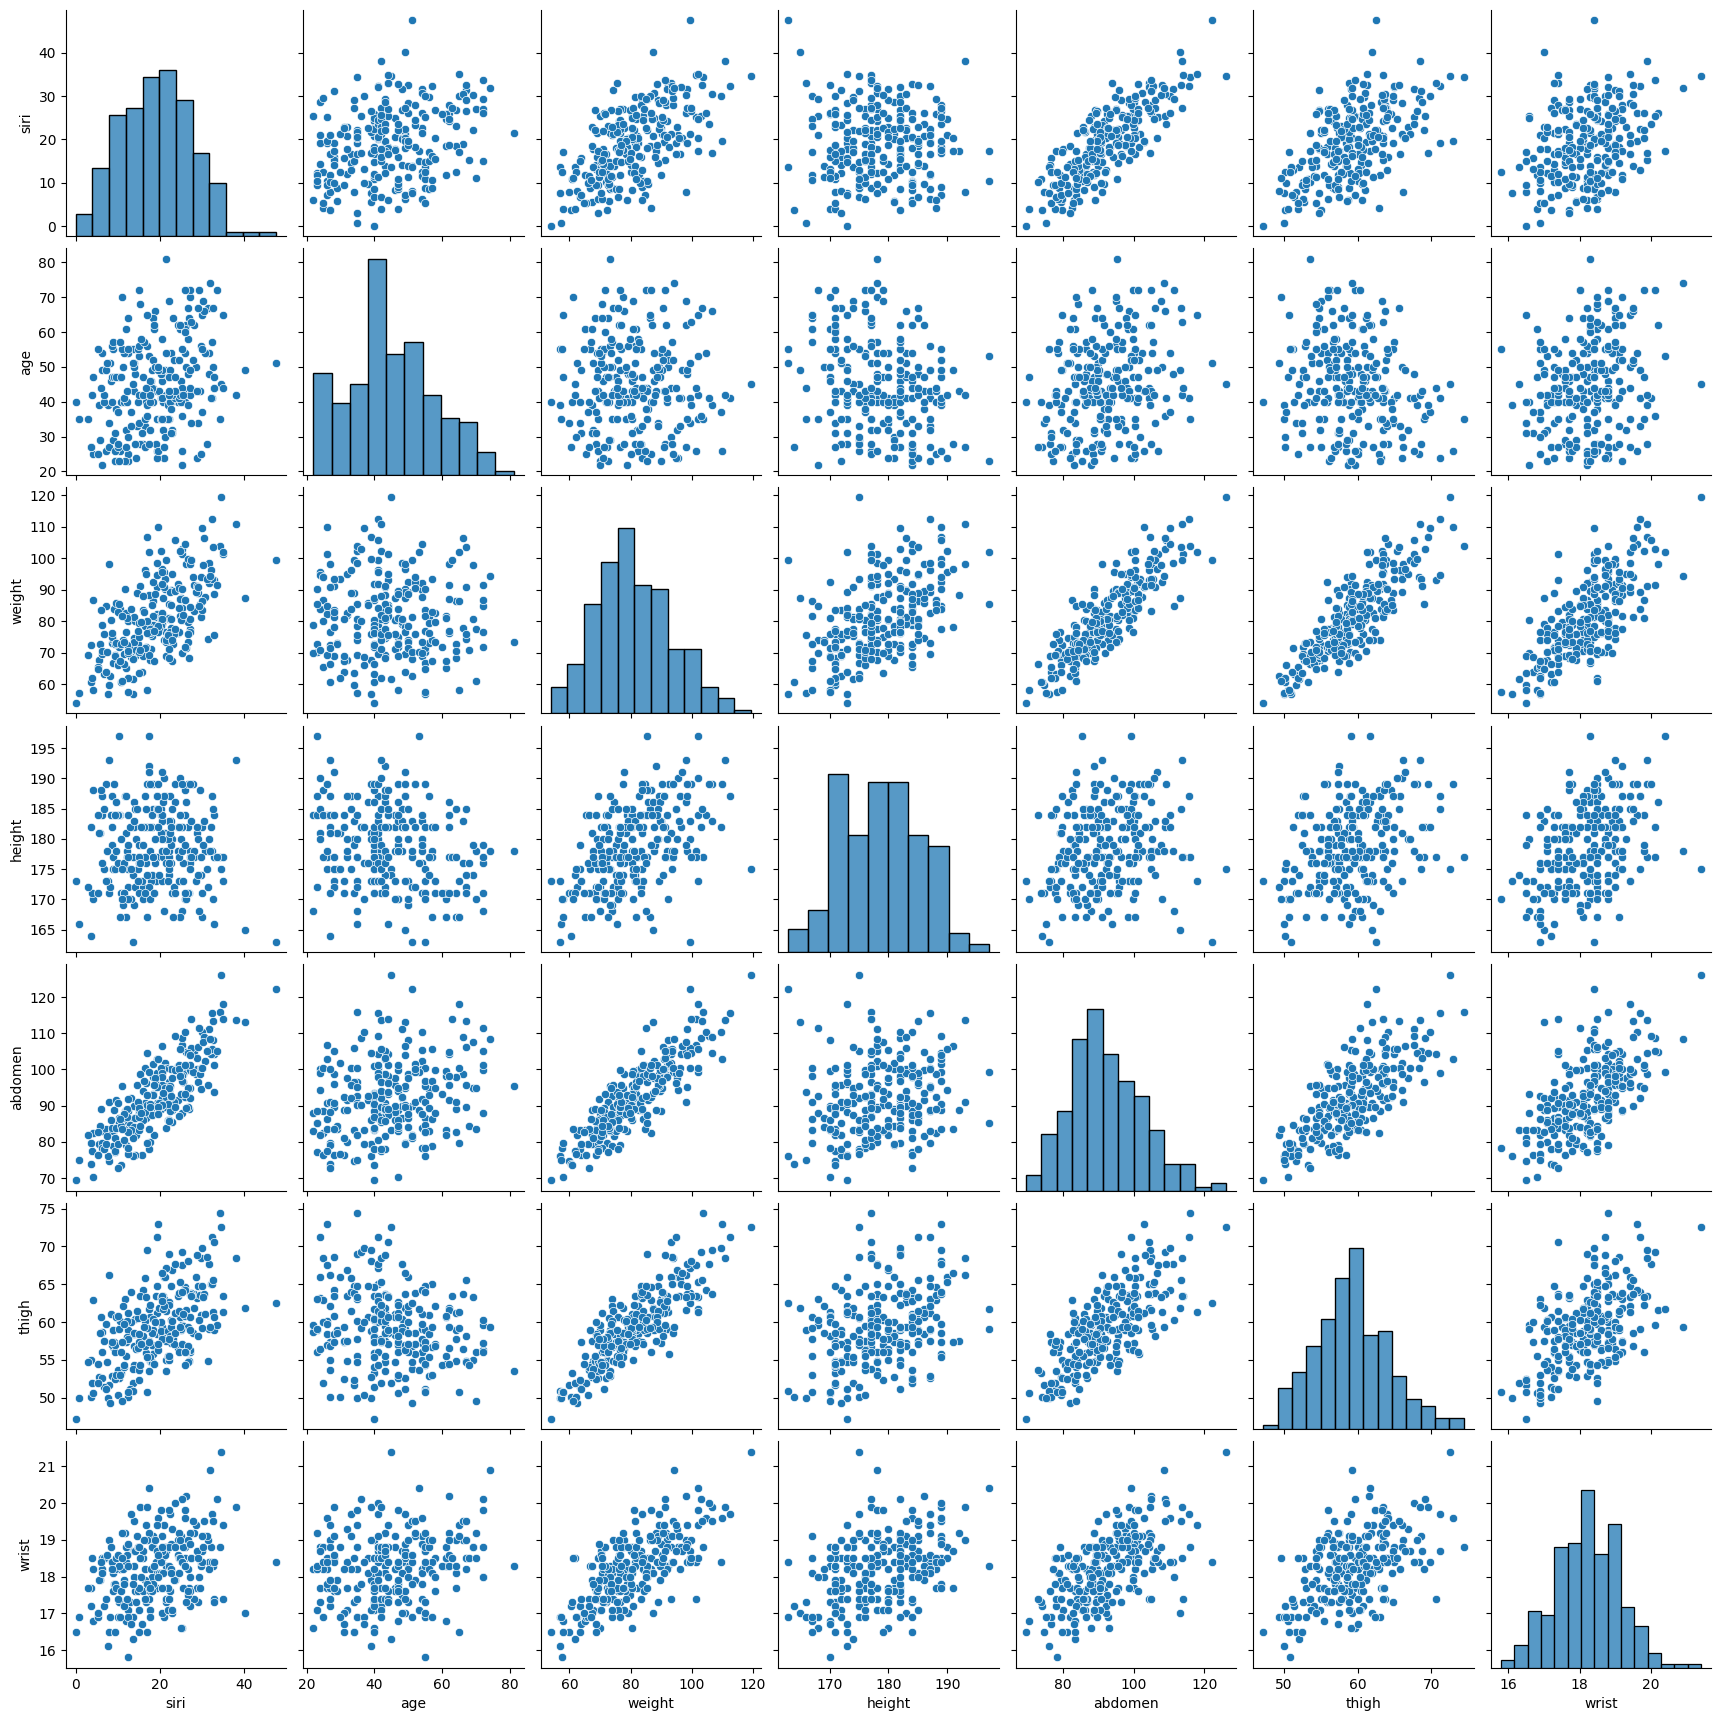

In [6]:
sns.pairplot(prod)

I'm going to try to predit wrist fat.

In [ ]:
!pip install preliz
!pip install bambi

In [8]:
import bambi as bmb

In [8]:
#used gemini

In [ ]:
model_glm = bmb.Model("wrist ~ siri + age + weight + height + abdomen + thigh", prod, family="gaussian", dropna=True)
idata_glm = model_glm.fit(idata_kwargs={'log_likelihood': True})

In [10]:
print("GLM Model Summary:")
print(az.summary(idata_glm, var_names=["~Intercept", "~sigma"]))

GLM Model Summary:
          mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
abdomen -0.027  0.013  -0.051   -0.003        0.0      0.0    1087.0   
age      0.026  0.004   0.019    0.033        0.0      0.0    1476.0   
height  -0.012  0.008  -0.028    0.002        0.0      0.0    1365.0   
siri    -0.029  0.008  -0.044   -0.013        0.0      0.0    1877.0   
thigh   -0.008  0.016  -0.039    0.020        0.0      0.0    1448.0   
weight   0.092  0.011   0.072    0.114        0.0      0.0    1024.0   

         ess_tail  r_hat  
abdomen    1267.0    1.0  
age        1200.0    1.0  
height     1178.0    1.0  
siri       1442.0    1.0  
thigh      1396.0    1.0  
weight     1034.0    1.0  


In [ ]:
# Define common parameters for B-splines
degree = 3 # Cubic splines
df_val = 4 # Degrees of freedom for automatic knot placement

# Prepare formula for B-spline model
# Using df to let Bambi automatically determine knot locations for each predictor
formula_bs = (
    "wrist ~ "
    "bs(siri, degree=degree, df=df_val) + "
    "bs(age, degree=degree, df=df_val) + "
    "bs(weight, degree=degree, df=df_val) + "
    "bs(height, degree=degree, df=df_val) + "
    "bs(abdomen, degree=degree, df=df_val) + "
    "bs(thigh, degree=degree, df=df_val)"
)

# Create and fit the B-spline model
model_spline = bmb.Model(formula_bs, prod, family="gaussian", dropna=True)
idata_spline = model_spline.fit(idata_kwargs={'log_likelihood': True})

In [12]:
print("B-Spline Model Summary:")
print(az.summary(idata_spline, var_names=["~Intercept", "~sigma"]))

B-Spline Model Summary:
                                           mean     sd  hdi_3%  hdi_97%  \
bs(abdomen, degree=degree, df=df_val)[0] -1.522  0.653  -2.724   -0.324   
bs(abdomen, degree=degree, df=df_val)[1] -0.494  0.609  -1.684    0.607   
bs(abdomen, degree=degree, df=df_val)[2] -2.351  0.863  -4.006   -0.816   
bs(abdomen, degree=degree, df=df_val)[3] -2.414  1.098  -4.484   -0.467   
bs(age, degree=degree, df=df_val)[0]      0.034  0.347  -0.653    0.664   
bs(age, degree=degree, df=df_val)[1]     -0.078  0.291  -0.656    0.428   
bs(age, degree=degree, df=df_val)[2]      1.289  0.440   0.462    2.108   
bs(age, degree=degree, df=df_val)[3]      1.455  0.480   0.562    2.335   
bs(height, degree=degree, df=df_val)[0]   0.440  0.518  -0.499    1.417   
bs(height, degree=degree, df=df_val)[1]   0.322  0.380  -0.339    1.103   
bs(height, degree=degree, df=df_val)[2]  -0.117  0.517  -1.094    0.838   
bs(height, degree=degree, df=df_val)[3]   0.111  0.522  -0.797    1.138   
b

/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


        rank    elpd_loo      p_loo  elpd_diff    weight         se       dse  \
glm        0 -213.043810   8.520355   0.000000  0.497647  11.879127  0.000000   
spline     1 -213.403706  26.109841   0.359896  0.502353  11.783611  6.016352   

        warning scale  
glm       False   log  
spline     True   log  


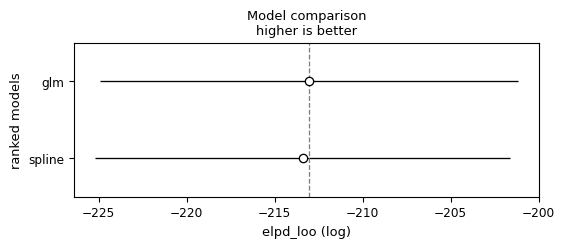

In [18]:
compare_models = az.compare({"glm": idata_glm, "spline": idata_spline}, ic="loo")
print(compare_models)
az.plot_compare(compare_models)
plt.show()

Glm is higher

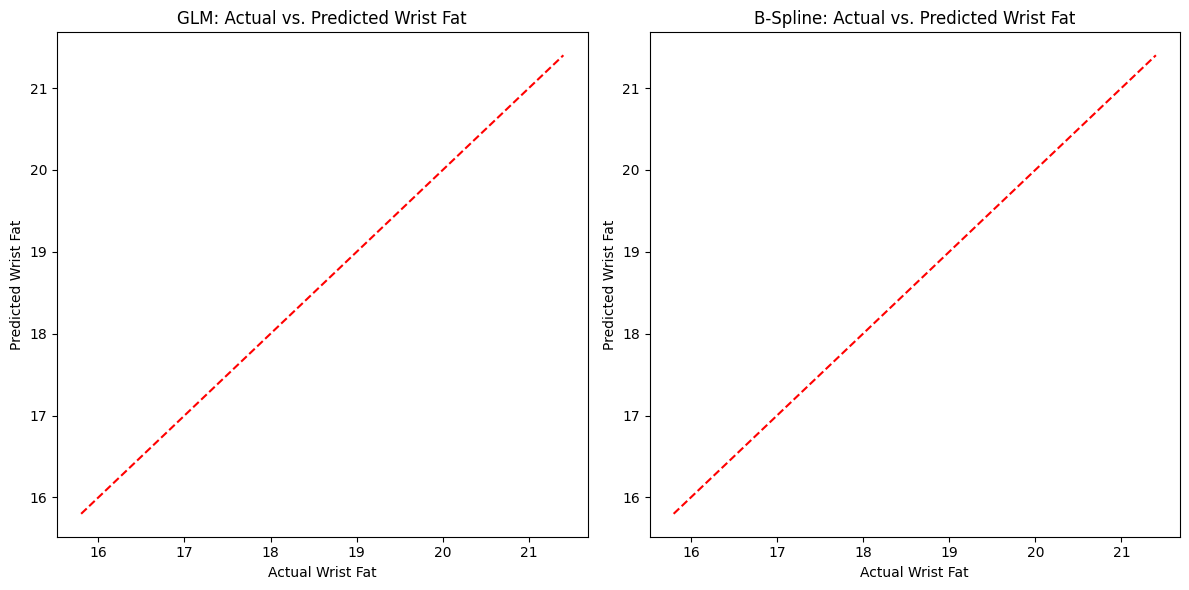

In [22]:
# First, ensure the data used for prediction is cleaned, matching the data used for fitting
prod_cleaned = prod.dropna()

# Get predictions for GLM
# Using prod_cleaned for prediction, and kind='response' returns the mean prediction directly
pred_glm = model_glm.predict(idata_glm, data=prod_cleaned, kind='response')

# Get predictions for B-spline model
# Using prod_cleaned for prediction, and kind='response' returns the mean prediction directly
pred_spline = model_spline.predict(idata_spline, data=prod_cleaned, kind='response')

# Plotting actual vs. predicted for GLM
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
# Use prod_cleaned["wrist"] for actual values to match the predicted data points
sns.scatterplot(x=prod_cleaned["wrist"], y=pred_glm)
plt.plot([prod_cleaned["wrist"].min(), prod_cleaned["wrist"].max()], [prod_cleaned["wrist"].min(), prod_cleaned["wrist"].max()], 'r--') # 45-degree line
plt.title('GLM: Actual vs. Predicted Wrist Fat')
plt.xlabel('Actual Wrist Fat')
plt.ylabel('Predicted Wrist Fat')

# Plotting actual vs. predicted for B-spline model
plt.subplot(1, 2, 2)
# Use prod_cleaned["wrist"] for actual values to match the predicted data points
sns.scatterplot(x=prod_cleaned["wrist"], y=pred_spline)
plt.plot([prod_cleaned["wrist"].min(), prod_cleaned["wrist"].max()], [prod_cleaned["wrist"].min(), prod_cleaned["wrist"].max()], 'r--') # 45-degree line
plt.title('B-Spline: Actual vs. Predicted Wrist Fat')
plt.xlabel('Actual Wrist Fat')
plt.ylabel('Predicted Wrist Fat')

plt.tight_layout()
plt.show()

/tmp/ipykernel_5243/1609224641.py:11: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


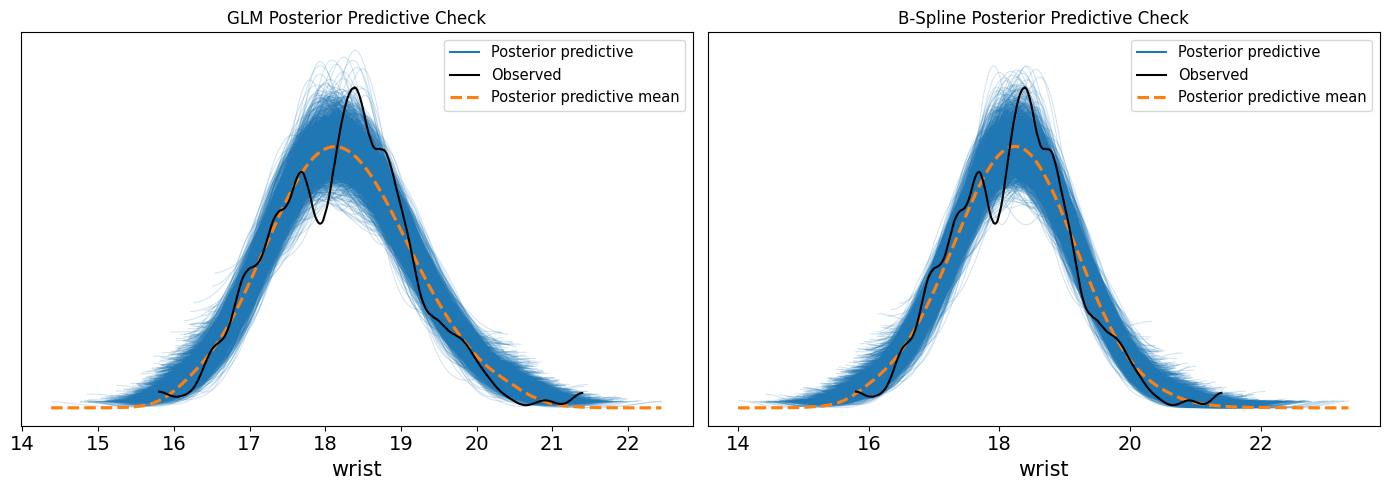

In [24]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Posterior predictive check for GLM
az.plot_ppc(idata_glm, ax=ax[0], data_pairs={"wrist": "wrist"})
ax[0].set_title('GLM Posterior Predictive Check')

# Posterior predictive check for B-spline model
az.plot_ppc(idata_spline, ax=ax[1], data_pairs={"wrist": "wrist"})
ax[1].set_title('B-Spline Posterior Predictive Check')

plt.tight_layout()
plt.show()

W

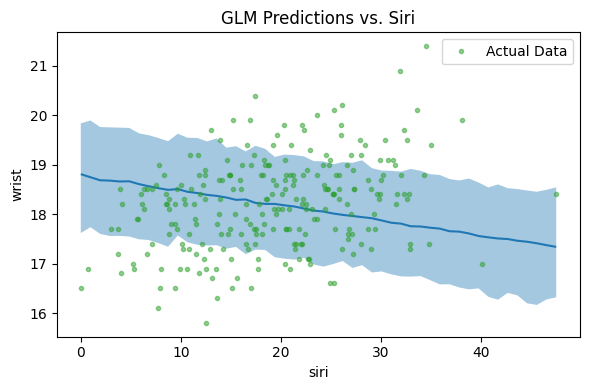

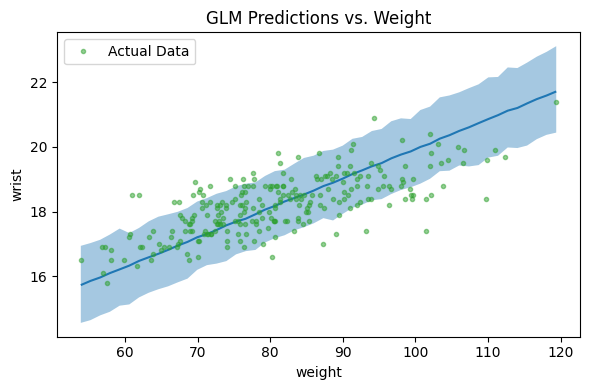

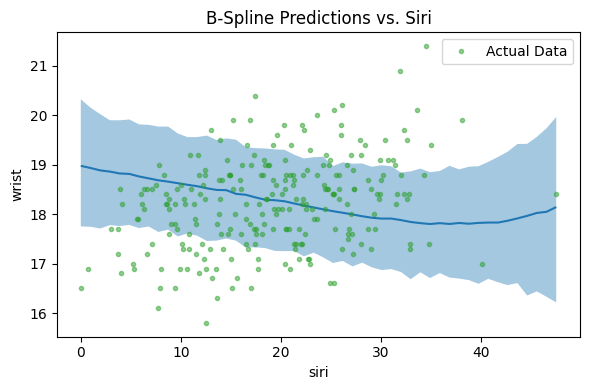

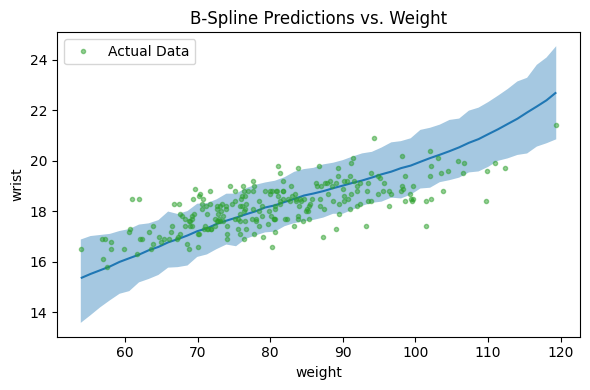

In [29]:
# GLM Predictions for 'siri'
fig_glm_siri, ax_glm_siri = bmb.interpret.plot_predictions(model_glm, idata_glm, 'siri',
                                                pps=True,
                                                fig_kwargs={"figsize": (6, 4)})
# Overlay actual data for 'siri'
ax_glm_siri[0].plot(prod_cleaned['siri'].values, prod_cleaned['wrist'].values, "C2.", alpha=0.5, label='Actual Data')
ax_glm_siri[0].legend()
ax_glm_siri[0].set_title('GLM Predictions vs. Siri')
plt.tight_layout()
plt.show()

# GLM Predictions for 'weight'
fig_glm_weight, ax_glm_weight = bmb.interpret.plot_predictions(model_glm, idata_glm, 'weight',
                                                pps=True,
                                                fig_kwargs={"figsize": (6, 4)})
# Overlay actual data for 'weight'
ax_glm_weight[0].plot(prod_cleaned['weight'].values, prod_cleaned['wrist'].values, "C2.", alpha=0.5, label='Actual Data')
ax_glm_weight[0].legend()
ax_glm_weight[0].set_title('GLM Predictions vs. Weight')
plt.tight_layout()
plt.show()

# B-Spline Predictions for 'siri'
fig_spline_siri, ax_spline_siri = bmb.interpret.plot_predictions(model_spline, idata_spline, 'siri',
                                                    pps=True,
                                                    fig_kwargs={"figsize": (6, 4)})
# Overlay actual data for 'siri'
ax_spline_siri[0].plot(prod_cleaned['siri'].values, prod_cleaned['wrist'].values, "C2.", alpha=0.5, label='Actual Data')
ax_spline_siri[0].legend()
ax_spline_siri[0].set_title('B-Spline Predictions vs. Siri')
plt.tight_layout()
plt.show()

# B-Spline Predictions for 'weight'
fig_spline_weight, ax_spline_weight = bmb.interpret.plot_predictions(model_spline, idata_spline, 'weight',
                                                    pps=True,
                                                    fig_kwargs={"figsize": (6, 4)})
# Overlay actual data for 'weight'
ax_spline_weight[0].plot(prod_cleaned['weight'].values, prod_cleaned['wrist'].values, "C2.", alpha=0.5, label='Actual Data')
ax_spline_weight[0].legend()
ax_spline_weight[0].set_title('B-Spline Predictions vs. Weight')
plt.tight_layout()
plt.show()

They are both very very close in terms of how well they are performing, even when looking at specific predictors. I think GLM did slightly better because if you look at the pair plot the relationships are all very linear which is what a GLM is using to make predictions.